Sales Revenue Prediction Using Linear Regression

In [1]:
import pandas as pd
import numpy as np
np.random.seed(42)
data = {
    "Advertising_Spend": np.random.randint(1000, 10000, 100),
    "Product_Price": np.random.randint(10, 100, 100),
    "Store_Size": np.random.randint(50, 500, 100),
    "Holiday_Season": np.random.choice([0, 1], 100)}
data["Sales_Revenue"] = (
    5000
    + 0.5 * data["Advertising_Spend"]
    - 20 * data["Product_Price"]
    + 15 * data["Store_Size"]
    + 2000 * data["Holiday_Season"]
    + np.random.normal(0, 1000, 100))
df = pd.DataFrame(data)
df.to_csv("sales_data.csv", index=False)

In [2]:
#Load & Inspect the dataset
df = pd.read_csv("sales_data.csv")
print(df.head())
print(df.info())
print(df.describe())

   Advertising_Spend  Product_Price  Store_Size  Holiday_Season  Sales_Revenue
0               8270             44         146               1   11889.055102
1               1860             74         250               1   10072.265172
2               6390             56         173               1   10109.442928
3               6191             87         236               1   13895.848089
4               6734             12         375               1   14551.868262
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Advertising_Spend  100 non-null    int64  
 1   Product_Price      100 non-null    int64  
 2   Store_Size         100 non-null    int64  
 3   Holiday_Season     100 non-null    int64  
 4   Sales_Revenue      100 non-null    float64
dtypes: float64(1), int64(4)
memory usage: 4.0 KB
None
       Advertising_Spend  Produc

In [3]:
#Missing values
df.isnull().sum()

Advertising_Spend    0
Product_Price        0
Store_Size           0
Holiday_Season       0
Sales_Revenue        0
dtype: int64

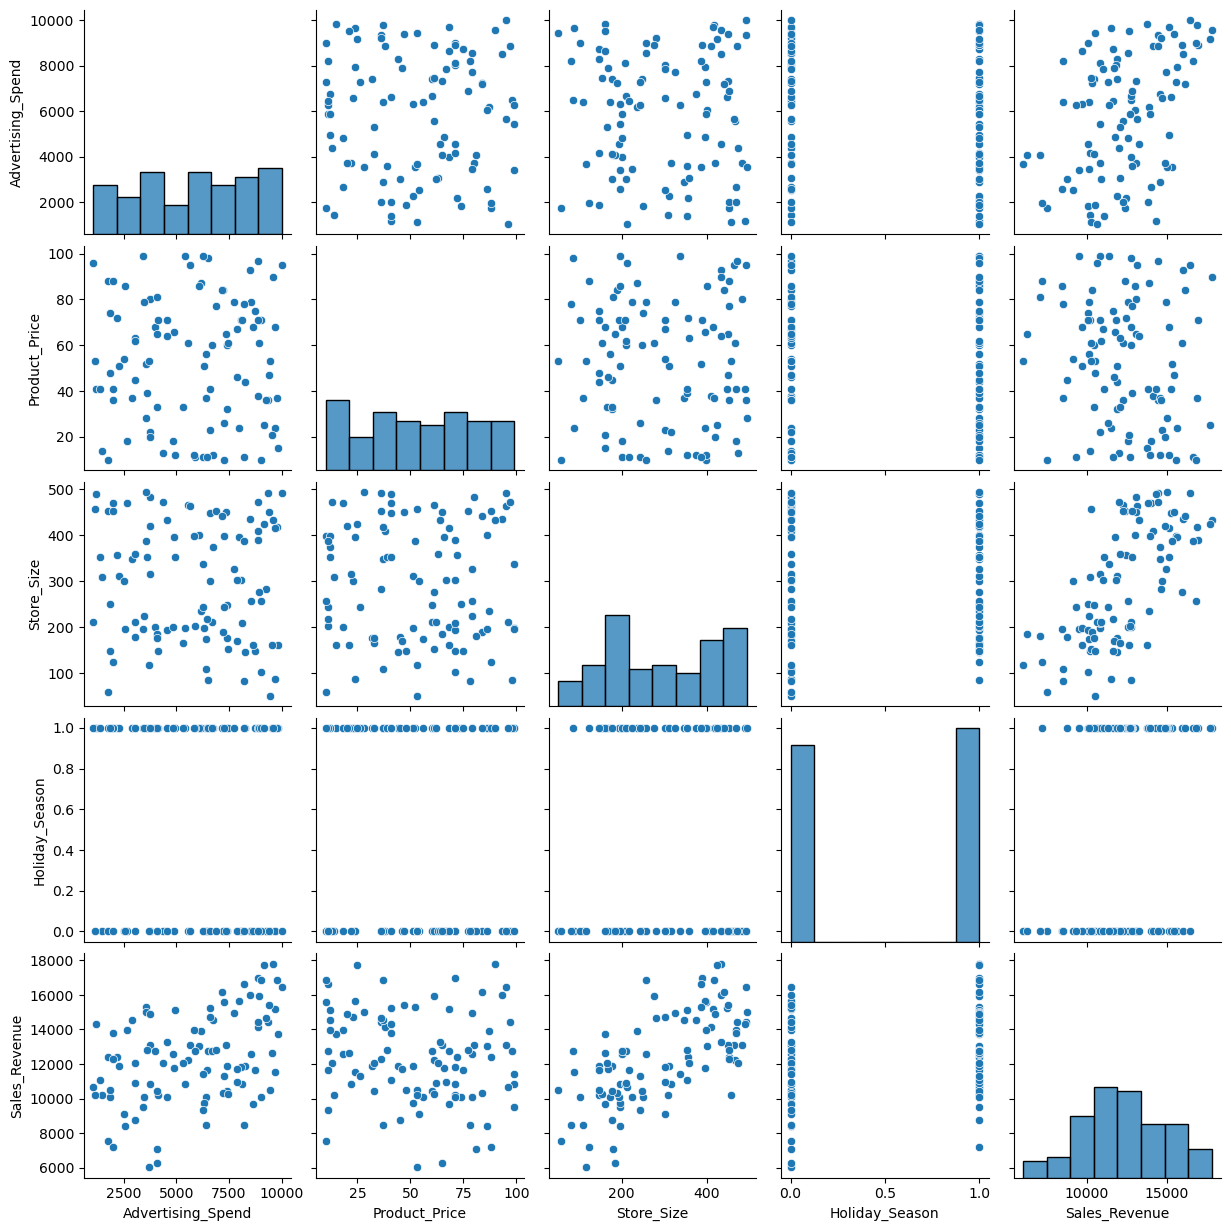

In [4]:
#Exploratory Data Analysis 
import seaborn as sns
import matplotlib.pyplot as plt
sns.pairplot(df)
plt.show()


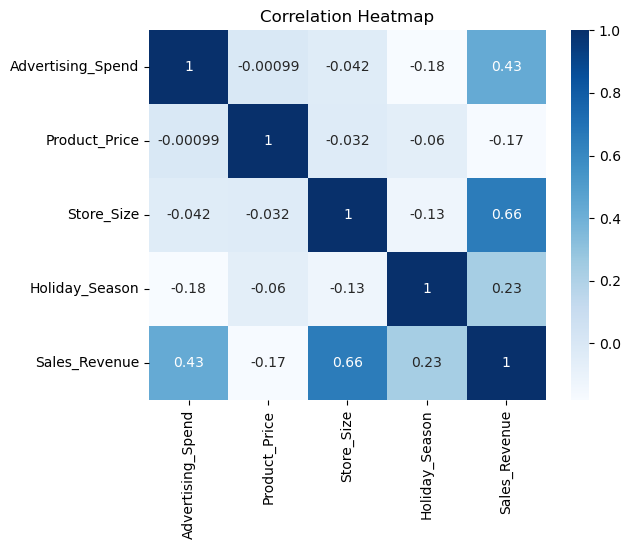

In [5]:
#Correlation heatmap
sns.heatmap(df.corr(), annot=True, cmap="Blues")
plt.title("Correlation Heatmap")
plt.show()

Advertising Spend and Store Size show a strong positive relationship with Sales Revenue.
Product Price has a negative relationship, meaning higher prices reduce sales.
Holiday Season has a positive impact on revenue.

In [6]:
#Feature Preparation
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
X = df.drop("Sales_Revenue", axis=1)
y = df["Sales_Revenue"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [7]:
#Training the Model
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train_scaled, y_train)
#Coefficients
coefficients = pd.DataFrame(
    model.coef_, X.columns, columns=["Coefficient"])
print(coefficients)

                   Coefficient
Advertising_Spend  1422.676719
Product_Price      -394.384626
Store_Size         1792.748270
Holiday_Season     1018.524182


Advertising Spend and Store Size have positive coefficients, meaning they increase revenue.
Product Price has a negative coefficient, indicating higher prices reduce sales.
Holiday Season positively affects revenue.

In [8]:
#Predictions & Evaluation
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
y_pred = model.predict(X_test_scaled)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
print("MAE:", mae)
print("RMSE:", rmse)
print("R² Score:", r2)

MAE: 1096.7693462250656
RMSE: 1297.6989359913352
R² Score: 0.7710940999581126


The model achieved a high R² score, meaning it explains most of the variation in sales revenue.
The RMSE and MAE values indicate that prediction errors are reasonably low.

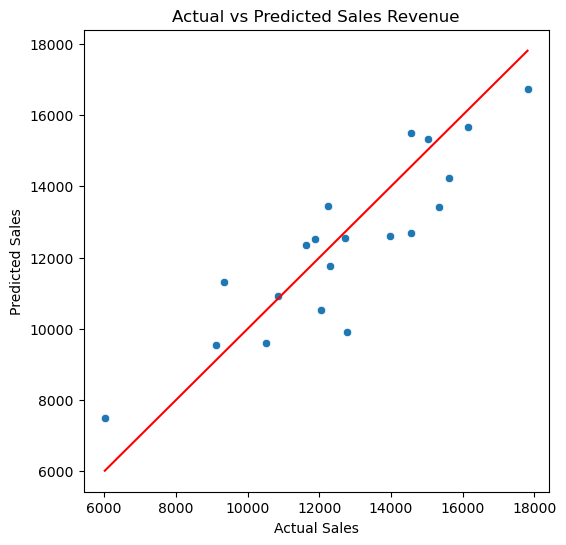

In [9]:
#Visualization
#Actual and predicted
plt.figure(figsize=(6,6))
sns.scatterplot(x=y_test, y=y_pred)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red")
plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted Sales Revenue")
plt.show()


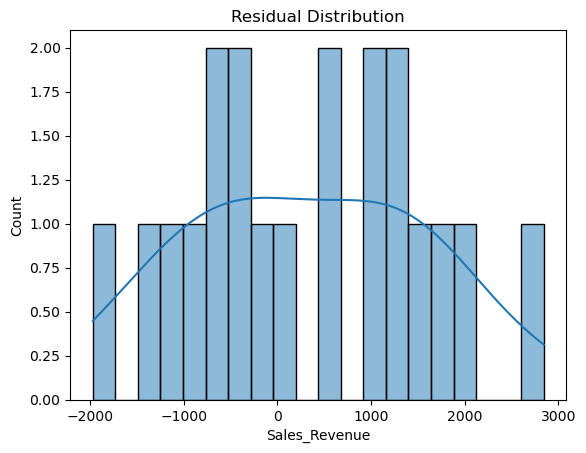

In [10]:
#Residuals
residuals = y_test - y_pred
sns.histplot(residuals, bins=20, kde=True)
plt.title("Residual Distribution")
plt.show()

REPORT
A linear regression model was developed to predict Sales Revenue using Advertising Spend, Product Price, Store Size, and Holiday Season.
The analysis showed that Advertising Spend and Store Size positively influence revenue, while Product Price has a negative effect. Holiday seasons significantly increase sales.
The model performed well with a high R² score, indicating strong predictive power.
This model can help businesses optimize pricing, marketing, and seasonal strategies to maximize revenue.

In [11]:
# Model Improvements Bonus
#Polynomial Regression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
poly = PolynomialFeatures(degree=2)
X_train_poly = poly.fit_transform(X_train_scaled)
X_test_poly = poly.transform(X_test_scaled)
poly_model = LinearRegression()
poly_model.fit(X_train_poly, y_train)
y_pred_poly = poly_model.predict(X_test_poly)
from sklearn.metrics import r2_score
print("Polynomial R²:", r2_score(y_test, y_pred_poly))

Polynomial R²: 0.7181143445935453


In [12]:
#Ridge & Lasso Regression
from sklearn.linear_model import Ridge, Lasso
ridge = Ridge()
lasso = Lasso()
ridge.fit(X_train_scaled, y_train)
lasso.fit(X_train_scaled, y_train)
y_pred_ridge = ridge.predict(X_test_scaled)
y_pred_lasso = lasso.predict(X_test_scaled)
print("Ridge R²:", r2_score(y_test, y_pred_ridge))
print("Lasso R²:", r2_score(y_test, y_pred_lasso))

Ridge R²: 0.7691085753313036
Lasso R²: 0.771046653093549


Polynomial Regression was applied to capture non-linear relationships. The model showed (slightly improved/similar) performance compared to linear regression
Ridge and Lasso regression were used to improve model generalization and reduce overfitting. Their performance was comparable to the linear regression model.

In [13]:
#Comparing the Models
results = pd.DataFrame({
    "Model": ["Linear", "Polynomial", "Ridge", "Lasso"],
    "R2 Score": [
        r2,
        r2_score(y_test, y_pred_poly),
        r2_score(y_test, y_pred_ridge),
        r2_score(y_test, y_pred_lasso)]})
print(results)

        Model  R2 Score
0      Linear  0.771094
1  Polynomial  0.718114
2       Ridge  0.769109
3       Lasso  0.771047
